In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
from scipy import interpolate 
cubic=interpolate.CubicSpline
import csaps
from math import log, sqrt, pi, exp
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

########################### DEFINE FUNCTIONS ########################################
# this is the black scholes formula for an european option
def d1(S,K,T,r,sigma,q):
    return(np.log(S/K)+(r-q+sigma**2/2.)*T)/(sigma*(T)**0.5)
def d2(S,K,T,r,sigma,q):
    return d1(S,K,T,r,sigma,q)-sigma*(T)**0.5
def bs_call(S,K,T,r,sigma,q):
    return S*np.exp(-q*T)*norm.cdf(d1(S,K,T,r,sigma,q))-K*np.exp(-r*T)*norm.cdf(d2(S,K,T,r,sigma,q))
def bs_put(S,K,T,r,sigma,q):
    return K*np.exp(-r*T)-S*np.exp(-q*T)+bs_call(S,K,T,r,sigma,q)

def construct_cdf(
    df_f: pd.DataFrame,
    secid: int = 108105,
    date: str = "2020-03-20",
    ref_date: str = "2020-02-28",
    mat: int = 91,
    step: float = 0.125,
    smooth: float = 0.1) -> pd.DataFrame:
    """
    Build a (risk-neutral) CDF/PDF and related quantities from an OTM option panel.

    Inputs (must exist in df_f for the chosen secid/Date/mat):
      - impl_strike, impl_volatility, delta_prime, rate, close, forwardprice, days

    Returns a DataFrame with:
      impl_strike, F (CDF), Ftilda (alt CDF), f (PDF), return, spot_return, impl_vol, impl_vol_der, delta, etc.
    """

    # ----- slice and basics -----
    panel = df_f[(df_f["days"] == mat) & (df_f["secid"] == secid)].copy()
    panel = panel[panel["Date"] == date].copy()
    if panel.empty:
        raise ValueError("No rows found for the given (secid, Date, mat).")

    # Averages/means used repeatedly (scalar summaries for this date/maturity)
    S_bar = panel["close"].mean()
    T_years = panel["days"].mean() / 365.0
    r_bar = panel["rate"].mean()
    # q is forward-implied dividend yield
    q_bar = (365.0 / panel["days"]) * np.log(panel["close"] / panel["forwardprice"] * np.exp(panel["rate"] * panel["days"] / 365.0))
    q_bar = q_bar.mean()

    # strike grid within (min, max) with a margin defined by `step`
    panel = panel.sort_values("impl_strike")
    K_min, K_max = panel["impl_strike"].min(), panel["impl_strike"].max()
    xgrid = np.linspace(K_min * (1 + step), K_max * (1 - step), num=400)

    # ----- helpers -----
    def iv_spline(x: np.ndarray, col: str = "impl_volatility", der: int = 0) -> np.ndarray:
        """Smoothed IV (or its derivative) evaluated at arbitrary strikes."""
        spl = csaps.CubicSmoothingSpline(panel["impl_strike"], panel[col], smooth=smooth)
        if der == 0:
            return spl(x)
        return spl.spline.derivative(nu=1)(x)

    def put_price(K: np.ndarray) -> np.ndarray:
        """BS put at strike K, using smoothed IV at K."""
        sigma = iv_spline(K, "impl_volatility", der=0)
        return bs_put(S_bar, K, T_years, r_bar, sigma, q_bar)

    # central difference step sizes (relative to K)
    h = step
    K = xgrid
    K_plus, K_minus = K * (1 + h), K * (1 - h)

    # ----- first derivative wrt K: dP/dK ≈ [P(K+) - P(K-)] / (2 K h) -----
    dP_dK = (put_price(K_plus) - put_price(K_minus)) / (2.0 * K * h)  # discounted CDF
    # ----- second derivative wrt K: d²P/dK² via central diff on the slopes -----
    # slopes at K+ and K-
    Kpp, Kpm = K_plus * (1 + h), K_plus * (1 - h)
    Kmp, Kmm = K_minus * (1 + h), K_minus * (1 - h)
    dP_dK_at_Kplus  = (put_price(Kpp) - put_price(Kpm)) / (2.0 * K_plus  * h)
    dP_dK_at_Kminus = (put_price(Kmp) - put_price(Kmm)) / (2.0 * K_minus * h)
    d2P_dK2 = (dP_dK_at_Kplus - dP_dK_at_Kminus) / (2.0 * K * h)       # discounted PDF

    # discount factor to move from discounted moments to actual (Breeden–Litzenberger)
    exp_rT = np.exp(r_bar * T_years)

    # ----- assemble output -----
    out = pd.DataFrame(index=np.arange(len(xgrid)))
    out["impl_strike"] = xgrid
    out["F"] = dP_dK * exp_rT                           # risk-neutral CDF
    out["f"] = d2P_dK2                                  # (kept discounted as in original; scale if needed)

    # alternative CDF (as in original code)
    out["Ftilda"] = (xgrid * dP_dK - put_price(xgrid)) * exp_rT / panel["forwardprice"].mean()

    # reference forwards to compute returns
    f0 = df_f[(df_f["days"] == mat) & (df_f["secid"] == secid) & (df_f["Date"] == ref_date)]["forwardprice"].mean()
    f1 = df_f[(df_f["days"] == mat) & (df_f["secid"] == secid) & (df_f["Date"] == date)]["forwardprice"].mean()

    out["Date"] = date
    out["secid"] = secid
    out["price"] = panel["forwardprice"].mean()
    out["base_price"] = f0
    out["return"] = xgrid / f0 - 1.0
    out["spot_return"] = f1 / f0 - 1.0

    # iv and its strike-derivative on the grid
    out["impl_vol"] = iv_spline(xgrid, "impl_volatility", der=0)
    out["impl_vol_der"] = iv_spline(xgrid, "impl_volatility", der=1)

    # traded range indicator (inside observed strike range)
    out["traded_range"] = 0
    mask_traded = (out["impl_strike"] > K_min) & (out["impl_strike"] < K_max)
    out.loc[mask_traded, "traded_range"] = 1

    out["delta"] =  iv_spline(xgrid, "delta_prime", der=0)

    # keep for reference
    out["step"] = step

    return out


# this function maps the cdf of two dates.
# It produces the q-to-q mapping across the densities in the two dates
def map_two_cdfs(
    cdf1: pd.DataFrame,
    cdf2: pd.DataFrame,
    F: str = "F",
    q_lower: float = 0.005,
    q_upper: float = 0.995,
) -> pd.DataFrame:
    """
    Map quantiles between two dates' CDFs.
    For each row in cdf1 (identified by its cumulative prob F at that strike),
    find the strike g in cdf2 such that CDF2(g) = CDF1(F).

    Parameters
    ----------
    cdf1 : DataFrame
        Must contain columns: ['impl_strike', F, 'spot_return'] 
        (spot_return will be overwritten with cdf2 mean).
    cdf2 : DataFrame
        Must contain columns: ['impl_strike', F, 'spot_return'].
    F : str, default 'F'
        Column name holding the (risk-neutral) CDF values.
    q_lower, q_upper : float
        Quantile bounds to avoid solving in the extreme tails.

    Returns
    -------
    DataFrame
        Copy of cdf1 with:
          - 'spot_return' set to mean of cdf2['spot_return']
          - 'g' filled where root-finding succeeded (strike in cdf2 matching cdf1's CDF level)
          - rows without a solution dropped
    """
    # Work on a copy to avoid side effects
    out = cdf1.copy()

    # Share the realized spot move from the second date (as in original code)
    out['spot_return'] = float(cdf2['spot_return'].mean())

    # Precompute bounds for interpolation/solving
    k_min, k_max = float(cdf2['impl_strike'].min()), float(cdf2['impl_strike'].max())
    F_min, F_max = float(cdf2[F].min()), float(cdf2[F].max())

    # Interpolant: for any strike x, return CDF2(x) on [k_min, k_max], clipped outside
    def cdf2_interp(x: float) -> float:
        return float(np.interp(x, cdf2['impl_strike'], cdf2[F], left=0.0, right=1.0))

    # Root target: find x (a strike) s.t. CDF2(x) - y = 0, where y = CDF1 at cdf1's strike
    def objective(x: float, y: float) -> float:
        return cdf2_interp(x) - y

    # Solve for each row where CDF1 level is well inside both cdf2 range and [q_lower, q_upper]
    valid = out.index[
        (out[F] >= max(F_min, q_lower)) &
        (out[F] <= min(F_max, q_upper))
    ]

    g_vals = {}
    for i in valid:
        y = float(out.at[i, F])
        try:
            sol = root_scalar(objective, args=(y,), bracket=[k_min, k_max])
            if sol.converged:
                g_vals[i] = sol.root
        except ValueError:
            # No sign change in bracket or bad inputs; skip this row
            continue

    # Assign solutions
    if g_vals:
        out.loc[list(g_vals.keys()), 'g'] = list(g_vals.values())
    # Drop rows without a solution (matches original behavior)
    out = out.dropna(subset=['g']).copy()

    return out


# this function computes the percentile of a given distribution
def percentile(n):
    def percentile_(x):
        return x.quantile(n)
    percentile_.__name__ = 'percentile_{:03.0f}'.format(n*1000)
    return percentile_


def compute_skew(df_volatility_surface: pd.DataFrame) -> pd.DataFrame:
    df = df_volatility_surface.copy()
    # per-row terms
    df["FtT"] = df["forwardprice"] * np.exp(df["rf_rate"] / 100.0 * df["days"]  / 365.0)   # TODO: add dividend yield
    df["ptT"] = 1.0 * np.exp(-df["rf_rate"] / 100.0 * df["days"]  / 365.0)

    # critical_point: within each (permno, month), the max impl_strike <= FtT for that row
    def add_critical_point(g: pd.DataFrame) -> pd.DataFrame:
        strikes_sorted = np.sort(g["impl_strike"].to_numpy())
        # For each FtT value, find insertion index then step back one
        idx = np.searchsorted(strikes_sorted, g["FtT"].to_numpy(), side="right") - 1
        crit = np.where(idx >= 0, strikes_sorted[idx], np.nan)
        g = g.copy()
        g["critical_point"] = crit
        return g

    df = df.groupby(["secid", "Date"], group_keys=False).apply(add_critical_point)

    # Filter out-of-money options
    is_call_otm = (df["cp_flag"] == "C") & (df["impl_strike"] >= df["critical_point"])
    is_put_otm  = (df["cp_flag"] == "P") & (df["impl_strike"] <  df["critical_point"])
    df = df[is_call_otm | is_put_otm].copy()

    # Sort within group by strike
    df = df.sort_values(["secid", "Date", "cp_flag", "impl_strike"])

    # Within (permno, month, cp_flag): lag/lead of strikes, then strike_diff
    df["nearest_lower"]  = df.groupby(["secid", "Date", "cp_flag"])["impl_strike"].shift(1)
    df["nearest_larger"] = df.groupby(["secid", "Date", "cp_flag"])["impl_strike"].shift(-1)
    df["strike_diff"]    = (df["nearest_larger"] - df["nearest_lower"]) / 2.0

    # Drop rows without both neighbors (finite middle points)
    df = df[np.isfinite(df["strike_diff"])].copy()

    # Formulas
    ratio = df["impl_strike"] / df["FtT"]
    # Protect against invalid values in log/sqrt with where; will become NaN if invalid
    safe_sqrt = np.sqrt(ratio.where(ratio >= 0))
    safe_log  = np.log(ratio.where(ratio > 0))

    df["skewness"] = ((6.0 / df["ptT"]) * safe_log * safe_sqrt * df["impl_premium"] /
                     (df["impl_strike"] ** 2) * df["strike_diff"])
    df["variance"] = ((2.0 / df["ptT"]) * safe_sqrt * df["impl_premium"] / 
                      (df["impl_strike"] ** 2) * df["strike_diff"])

    # Summarize per (permno, month)
    agg_upper = df.loc[df["cp_flag"] == "C"].groupby(["secid", "Date"])["skewness"].sum(min_count=1).rename("upperSKEW")
    agg_lower = df.loc[df["cp_flag"] == "P"].groupby(["secid", "Date"])["skewness"].sum(min_count=1).rename("lowerSKEW")
    agg_var   = df.groupby(["secid", "Date"])["variance"].sum(min_count=1).rename("variance")

    out = (
        pd.concat([agg_upper, agg_lower, agg_var], axis=1)
          .reset_index()
    )
    out["SKEW"] = out["upperSKEW"].fillna(0.0) + out["lowerSKEW"].fillna(0.0)

    # Optional: order columns to mirror R output
    out = out[["secid", "Date", "upperSKEW", "lowerSKEW", "SKEW", "variance"]]

    return out



def compute_skew_days(df_volatility_price_new: pd.DataFrame,
                                  annualize: bool = True,
                                  min_T: float = 1e-6) -> pd.DataFrame:
    """
    Compute upperSKEW, lowerSKEW, SKEW, and variance per (secid, Date, days).
    - 'days' is the days-to-maturity column (integer)
    - annualize=True divides by each row’s Tmaturity (days/365)
    """

    dt = df_volatility_price_new.copy()

    # --- ensure required columns exist ---
    required = ["secid", "Date", "days", "cp_flag", "impl_strike", 
                "impl_premium", "forwardprice", "rf_rate"]
    missing = [c for c in required if c not in dt.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")

    # --- maturity setup ---
    dt["days"] = dt["days"].astype(int)
    dt["Tmaturity"] = (dt["days"].astype(float) / 365.0).clip(lower=min_T)

    # --- forward & discount ---
    dt["FtT"] = dt["forwardprice"] * np.exp(dt["rf_rate"] / 100.0 * dt["Tmaturity"])   # TODO: add dividend yield
    dt["ptT"] = np.exp(-(dt["rf_rate"] / 100.0) * dt["Tmaturity"])

    # --- per-row critical strike: max K <= FtT (fallback to min(K)) ---
    def add_critical_point(g: pd.DataFrame) -> pd.DataFrame:
        Ks = np.sort(g["impl_strike"].unique())
        idx = np.searchsorted(Ks, g["FtT"].to_numpy(), side="right") - 1
        idx = np.where(idx < 0, 0, idx)  # fallback to min(K)
        gg = g.copy()
        gg["critical_point"] = Ks[idx]
        return gg

    grp_keys = ["secid", "Date", "days"]

    key_df = dt[grp_keys].copy()
    dt = dt.groupby(grp_keys, group_keys=False).apply(add_critical_point)

    for col in grp_keys:
        dt[col] = key_df[col].values

    # --- OTM filter ---
    is_call_otm = (dt["cp_flag"] == "C") & (dt["impl_strike"] >= dt["critical_point"])
    is_put_otm  = (dt["cp_flag"] == "P") & (dt["impl_strike"] <  dt["critical_point"])
    dt_otm = dt[is_call_otm | is_put_otm].copy()

    # --- strike spacing (half-gap interior only) ---
    dt_otm = dt_otm.sort_values(grp_keys + ["cp_flag", "impl_strike"])
    gb = dt_otm.groupby(grp_keys + ["cp_flag"])
    dt_otm["K_prev"] = gb["impl_strike"].shift(1)
    dt_otm["K_next"] = gb["impl_strike"].shift(-1)
    dt_otm["strike_diff"] = (dt_otm["K_next"] - dt_otm["K_prev"]) / 2.0
    dt_otm = dt_otm[np.isfinite(dt_otm["strike_diff"])].copy()

    # --- coefficients ---
    if annualize:
        dt_otm["coef_skew"] = 6.0 / (dt_otm["ptT"] * dt_otm["Tmaturity"])
        dt_otm["coef_var"]  = 2.0 / (dt_otm["ptT"] * dt_otm["Tmaturity"])
    else:
        dt_otm["coef_skew"] = 6.0 / dt_otm["ptT"]
        dt_otm["coef_var"]  = 2.0 / dt_otm["ptT"]

    # --- integrands ---
    ratio = dt_otm["impl_strike"] / dt_otm["FtT"]
    safe_ratio = ratio.where(ratio > 0)
    root_ratio = np.sqrt(np.maximum(safe_ratio, 0))

    dt_otm["skew_row"] = (
        dt_otm["coef_skew"]
        * np.log(safe_ratio)
        * root_ratio
        * dt_otm["impl_premium"]
        / (dt_otm["impl_strike"] ** 2)
        * dt_otm["strike_diff"]
    )
    dt_otm["var_row"] = (
        dt_otm["coef_var"]
        * root_ratio
        * dt_otm["impl_premium"]
        / (dt_otm["impl_strike"] ** 2)
        * dt_otm["strike_diff"]
    )

    # --- aggregate per (secid, Date, maturity_key) ---
    df_skew_all = (
        dt_otm.groupby(grp_keys, as_index=False)
        .apply(lambda g: pd.Series({
            "upperSKEW": g.loc[g["cp_flag"] == "C", "skew_row"].sum(skipna=True),
            "lowerSKEW": g.loc[g["cp_flag"] == "P", "skew_row"].sum(skipna=True),
            "SKEW": g["skew_row"].sum(skipna=True),
            "variance": g["var_row"].sum(skipna=True),
        }))
        .reset_index(drop=True)
        .sort_values(grp_keys)
    )

    return df_skew_all[["secid", "Date", "days", "upperSKEW", "lowerSKEW", "SKEW", "variance"]]

In [2]:
option_panel = pd.read_parquet("./data/processed/options_fomc_panel_1996_2023.parquet")
option_panel["secid"] = option_panel["secid"].astype(int)
option_panel = option_panel.rename(columns={"spx_price": "close"})
df_skewness = compute_skew_days(option_panel)
option_panel

,secid,Date,cp_flag,delta,days,impl_volatility,impl_premium,impl_strike,fomc_dummy,vix,rf_rate,close,monetary_policy_shock,T_years,dividend_yield,forwardprice,vix_stress_75
0,108105,1996-01-04,C,10.0,30.0,0.096883,0.803134,642.7569,0.0,13.78,5.19,617.70,NaN,0.082192,0.0,620.340584,0
1,108105,1996-01-04,C,15.0,30.0,0.098895,1.343892,638.7863,0.0,13.78,5.19,617.70,NaN,0.082192,0.0,620.340584,0
2,108105,1996-01-04,C,20.0,30.0,0.100675,1.963859,635.5488,0.0,13.78,5.19,617.70,NaN,0.082192,0.0,620.340584,0
3,108105,1996-01-04,C,25.0,30.0,0.101514,2.643503,632.5961,0.0,13.78,5.19,617.70,NaN,0.082192,0.0,620.340584,0
4,108105,1996-01-04,C,30.0,30.0,0.102137,3.392095,629.8998,0.0,13.78,5.19,617.70,NaN,0.082192,0.0,620.340584,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
946963,108105,2023-08-31,P,-30.0,365.0,0.181898,173.272200,4362.9710,0.0,13.57,5.37,4507.66,NaN,1.000000,0.0,4756.338606,0
946964,108105,2023-08-31,P,-25.0,365.0,0.193825,144.806200,4220.6430,0.0,13.57,5.37,4507.66,NaN,1.000000,0.0,4756.338606,0
946965,108105,2023-08-31,P,-20.0,365.0,0.208327,116.672600,4048.1250,0.0,13.57,5.37,4507.66,NaN,1.000000,0.0,4756.338606,0
946966,108105,2023-08-31,P,-15.0,365.0,0.225626,88.084530,3832.2170,0.0,13.57,5.37,4507.66,NaN,1.000000,0.0,4756.338606,0


In [3]:
# The liquidity is typically concentrated on out of money options instead of in the money options.
# this uses put call parity so that we always rely on out of the money option prices 
# to estimate our risk neutral density
# this selects out of the money options 
df_put_otm =option_panel[((option_panel.cp_flag=='P') & 
                          (option_panel.impl_strike<option_panel.forwardprice))].copy()
# this applies put call parity to transfer OTM put to synthetic call with the same strike:
df_put_otm["discount_factor"] = np.exp(-df_put_otm["rf_rate"] / 100 * df_put_otm["days"] / 365)

# Apply the parity: for puts, adjust premium to synthetic call premium
# put–call parity:  C = P + (F - K)e^{-rT}
df_put_otm["impl_premium"] = (
    df_put_otm["impl_premium"]
    + (df_put_otm["forwardprice"] - df_put_otm["impl_strike"]) 
    * df_put_otm["discount_factor"]
)
del df_put_otm['discount_factor']

df_put_otm['delta_prime'] = df_put_otm.delta + 100
df_put_otm = df_put_otm[~(df_put_otm.delta==50)]
df_put_otm['cp_flag'] = 'C'
df_put_otm=df_put_otm[~(df_put_otm.delta_prime==50)]


df_call_otm = option_panel[((option_panel.cp_flag=='C') & 
                            (option_panel.impl_strike>=option_panel.forwardprice))].copy()
df_call_otm['delta_prime']=df_call_otm.delta

df_f = pd.concat([df_put_otm, df_call_otm])
df_f.sort_values(['secid','days','Date'],inplace=True)
df_f["rate"] = df_f["rf_rate"] / 100

df_f.tail(10)

,secid,Date,cp_flag,delta,days,impl_volatility,impl_premium,impl_strike,fomc_dummy,vix,rf_rate,close,monetary_policy_shock,T_years,dividend_yield,forwardprice,vix_stress_75,delta_prime,rate
946966,108105,2023-08-31,C,-15.0,365.0,0.225626,963.889712,3832.217,0.0,13.57,5.37,4507.66,NaN,1.0,0.0,4756.338606,0,85.0,0.0537
946967,108105,2023-08-31,C,-10.0,365.0,0.244777,1197.904700,3553.816,0.0,13.57,5.37,4507.66,NaN,1.0,0.0,4756.338606,0,90.0,0.0537
946883,108105,2023-08-31,C,10.0,365.0,0.118052,24.073660,5513.719,0.0,13.57,5.37,4507.66,NaN,1.0,0.0,4756.338606,0,10.0,0.0537
946884,108105,2023-08-31,C,15.0,365.0,0.119872,39.958890,5367.017,0.0,13.57,5.37,4507.66,NaN,1.0,0.0,4756.338606,0,15.0,0.0537
946885,108105,2023-08-31,C,20.0,365.0,0.122537,58.461650,5255.869,0.0,13.57,5.37,4507.66,NaN,1.0,0.0,4756.338606,0,20.0,0.0537
946886,108105,2023-08-31,C,25.0,365.0,0.125709,79.803850,5161.596,0.0,13.57,5.37,4507.66,NaN,1.0,0.0,4756.338606,0,25.0,0.0537
946887,108105,2023-08-31,C,30.0,365.0,0.129288,104.309000,5076.085,0.0,13.57,5.37,4507.66,NaN,1.0,0.0,4756.338606,0,30.0,0.0537
946888,108105,2023-08-31,C,35.0,365.0,0.133390,132.533700,4995.223,0.0,13.57,5.37,4507.66,NaN,1.0,0.0,4756.338606,0,35.0,0.0537
946889,108105,2023-08-31,C,40.0,365.0,0.138157,165.246100,4916.037,0.0,13.57,5.37,4507.66,NaN,1.0,0.0,4756.338606,0,40.0,0.0537
946890,108105,2023-08-31,C,45.0,365.0,0.143628,203.317300,4835.796,0.0,13.57,5.37,4507.66,NaN,1.0,0.0,4756.338606,0,45.0,0.0537


In [4]:
# Extract clean date objects (no time)
fomc_dates = (
    pd.to_datetime(df_f.loc[df_f['fomc_dummy'] == 1.0, 'Date'])
    .dt.normalize()                # keeps datetime64[ns], removes time part
    .drop_duplicates()
    .sort_values()
    .tolist()
)

full_dates = (
    pd.to_datetime(df_f['Date'])
    .dt.normalize()
    .drop_duplicates()
    .sort_values()
    .tolist()
)

# Build dictionary
event_dates = {}

for d in fomc_dates:
    if d in full_dates:
        idx = full_dates.index(d)
        prev_date = full_dates[idx - 1] if idx > 0 else None
        next_date = full_dates[idx + 1] if idx < len(full_dates) - 1 else None
    else:
        prev_date = next_date = None

    event_dates[d] = {
        "prev_date": prev_date,
        "next_date": next_date
    }

event_dates

{Timestamp('1996-01-31 00:00:00'): {'prev_date': Timestamp('1996-01-30 00:00:00'),
  'next_date': Timestamp('1996-02-01 00:00:00')},
 Timestamp('1996-03-26 00:00:00'): {'prev_date': Timestamp('1996-03-25 00:00:00'),
  'next_date': Timestamp('1996-03-27 00:00:00')},
 Timestamp('1996-05-21 00:00:00'): {'prev_date': Timestamp('1996-05-20 00:00:00'),
  'next_date': Timestamp('1996-05-22 00:00:00')},
 Timestamp('1996-07-03 00:00:00'): {'prev_date': Timestamp('1996-07-02 00:00:00'),
  'next_date': Timestamp('1996-07-05 00:00:00')},
 Timestamp('1996-08-20 00:00:00'): {'prev_date': Timestamp('1996-08-19 00:00:00'),
  'next_date': Timestamp('1996-08-21 00:00:00')},
 Timestamp('1996-09-24 00:00:00'): {'prev_date': Timestamp('1996-09-23 00:00:00'),
  'next_date': Timestamp('1996-09-25 00:00:00')},
 Timestamp('1996-11-13 00:00:00'): {'prev_date': Timestamp('1996-11-12 00:00:00'),
  'next_date': Timestamp('1996-11-14 00:00:00')},
 Timestamp('1996-12-17 00:00:00'): {'prev_date': Timestamp('1996-12-1

        secid       Date  days  upperSKEW  lowerSKEW      SKEW  variance
24376  108105 2020-03-20    30   0.017343  -0.054296 -0.036954  0.234922
24377  108105 2020-03-20    91   0.014474  -0.068535 -0.054060  0.180133
24378  108105 2020-03-20   182   0.012617  -0.058662 -0.046045  0.143075
24379  108105 2020-03-20   365   0.010151  -0.046319 -0.036167  0.099599
24384  108105 2020-03-24    30   0.016683  -0.038399 -0.021716  0.199635
24385  108105 2020-03-24    91   0.010693  -0.033779 -0.023087  0.118634
24386  108105 2020-03-24   182   0.008017  -0.029849 -0.021832  0.085027
24387  108105 2020-03-24   365   0.006852  -0.023348 -0.016496  0.058780


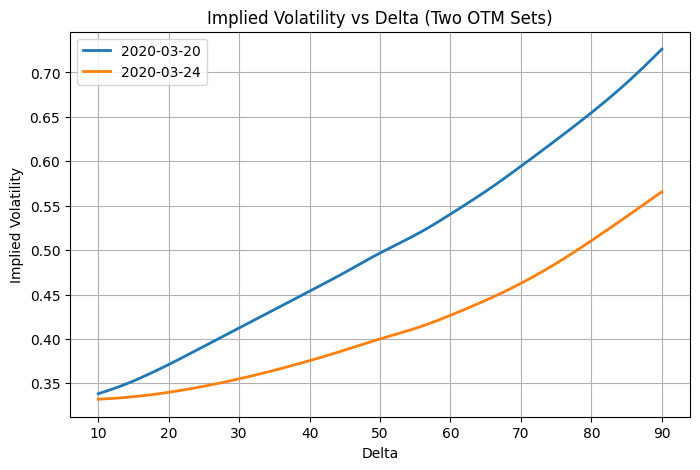

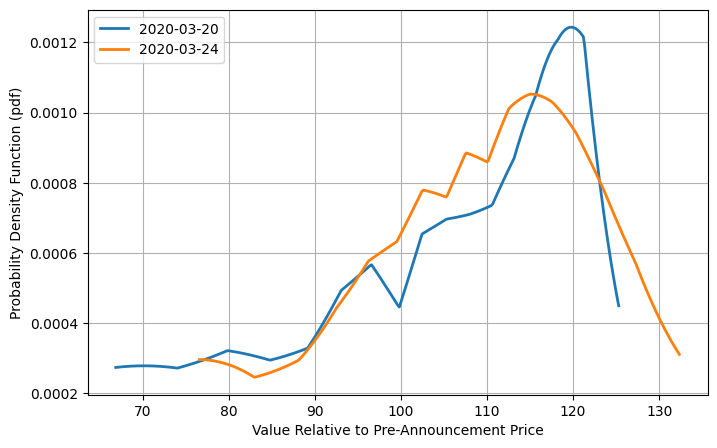

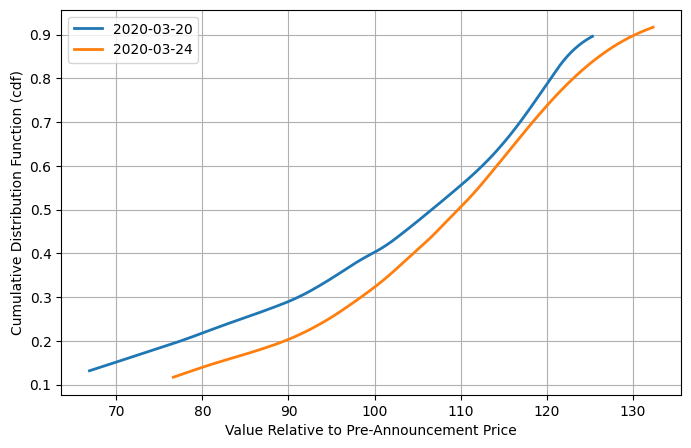

In [5]:
step=0.00001
smooth=0.0015
save=True
secid=108105

test_date = list(event_dates.keys())[100]

date0 = "2020-03-20" #event_dates[test_date]["prev_date"]
date1 = "2020-03-24" #event_dates[test_date]["next_date"]
ref_date=date0
mat=91

cdf1 = construct_cdf(df_f, mat=mat, secid=secid, 
                   date=date0, ref_date=ref_date,
                   step=step,smooth=smooth)
cdf2 = construct_cdf(df_f, mat=mat,secid=secid,
                   date=date1, ref_date=ref_date,
                   step=step,smooth=smooth)

cdf1_mapped = map_two_cdfs(cdf1, cdf2)
cdf1_mapped = cdf1_mapped[cdf1_mapped.traded_range==1]
cdf1_mapped['sccr']=cdf1_mapped['g']/cdf1_mapped['impl_strike']-1
#print(cdf1_mapped['impl_strike'].iloc[-30:-1])
#print(cdf1_mapped['sccr'].iloc[0]/cdf1_mapped['sccr'].iloc[-1])
#print(cdf1_mapped['sccr'].iloc[0])

cdf = pd.concat([cdf1_mapped, cdf2])

#print(str(secid)+str((cdf1.F.diff()<0).any()| (cdf2.F.diff()<0).any()))
cdf['moneyness']  = 100.0 * cdf['impl_strike'] / cdf['base_price']


cdf0 = cdf[cdf['Date']==date0]
cdf1 = cdf[cdf['Date']==date1]

df_skewness_event = df_skewness[(df_skewness['Date']==date0)|(df_skewness['Date']==date1)]
print(df_skewness_event)

plt.figure(figsize=(8,5))  # optional: set figure size
# plot both lines with labels
plt.plot(cdf0["delta"], cdf0["impl_vol"], label=date0, linewidth=2)
plt.plot(cdf1["delta"], cdf1["impl_vol"], label=date1, linewidth=2)
# add labels, title, legend, grid
plt.xlabel("Delta")
plt.ylabel("Implied Volatility")
plt.title("Implied Volatility vs Delta (Two OTM Sets)")
plt.legend()
plt.grid(True)
plt.show()



plt.figure(figsize=(8,5))  # optional: set figure size
# dashed black for before, solid black for after
plt.plot(cdf0["moneyness"], cdf0["f"], label=date0, linewidth=2)
plt.plot(cdf1["moneyness"], cdf1["f"], label=date1, linewidth=2)
plt.xlabel('Value Relative to Pre-Announcement Price')      # "moneyness" label
plt.ylabel('Probability Density Function (pdf)')        # "f" is the CDF in your labels
plt.legend()
plt.grid(True)
plt.show()
plt.show()

plt.figure(figsize=(8,5))  # optional: set figure size
# dashed black for before, solid black for after
plt.plot(cdf0["moneyness"], cdf0["F"], label=date0, linewidth=2)
plt.plot(cdf1["moneyness"], cdf1["F"], label=date1, linewidth=2)
plt.xlabel('Value Relative to Pre-Announcement Price')      # "moneyness" label
plt.ylabel('Cumulative Distribution Function (cdf)')        # "F" is the CDF in your labels
plt.legend()
plt.grid(True)
plt.show()
plt.show()

In [6]:
from tqdm import tqdm

def process_event_window_analysis(df_f: pd.DataFrame, 
                                event_dates: dict,
                                maturities: list = [30, 91, 182, 365],
                                step: float = 0.00001,
                                smooth: float = 0.0015,
                                secid: int = 108105) -> dict:
    """
    Process event window analysis for FOMC dates
    """
    
    all_distributions = []
    all_quantile_mappings = []
    
    # Process each event window and maturity with progress bar
    for event_date, window in tqdm(event_dates.items(), desc="Processing events"):
        t_minus_1 = window["prev_date"]
        t0 = event_date
        t_plus_1 = window["next_date"]
        
        if not all([t_minus_1, t_plus_1]):
            continue
            
        for maturity in maturities:
            try:
                # Construct CDFs for all three dates in window
                cdf_t_minus_1 = construct_cdf(
                    df_f, secid=secid, date=t_minus_1, ref_date=t_minus_1,
                    mat=maturity, step=step, smooth=smooth
                )
                cdf_t0 = construct_cdf(
                    df_f, secid=secid, date=t0, ref_date=t_minus_1,
                    mat=maturity, step=step, smooth=smooth
                )
                cdf_t_plus_1 = construct_cdf(
                    df_f, secid=secid, date=t_plus_1, ref_date=t_minus_1,
                    mat=maturity, step=step, smooth=smooth
                )
                
                # Add event window identifiers
                for cdf, position in [(cdf_t_minus_1, 't-1'), 
                                    (cdf_t0, 't0'), 
                                    (cdf_t_plus_1, 't+1')]:
                    cdf['event_date'] = event_date
                    cdf['window_position'] = position
                    cdf['maturity_days'] = maturity
                    all_distributions.append(cdf)
                
                # Quantile mapping
                mapping_t_minus_1_to_t0 = map_two_cdfs(cdf_t_minus_1, cdf_t0)
                mapping_t_minus_1_to_t_plus_1 = map_two_cdfs(cdf_t_minus_1, cdf_t_plus_1)
                
                # Add identifiers to mappings
                for mapping_df, period in [(mapping_t_minus_1_to_t0, 't-1_to_t0'),
                                         (mapping_t_minus_1_to_t_plus_1, 't-1_to_t+1')]:
                    mapping_df['event_date'] = event_date
                    mapping_df['mapping_period'] = period
                    mapping_df['maturity_days'] = maturity
                    mapping_df['sccr'] = mapping_df['g'] / mapping_df['impl_strike'] - 1
                    all_quantile_mappings.append(mapping_df)
                        
            except Exception as e:
                print(f"Error processing event {event_date}, maturity {maturity}: {e}")
                continue
    
    # Combine results
    distribution_df = pd.concat(all_distributions, ignore_index=True) if all_distributions else pd.DataFrame()
    quantile_mapping_df = pd.concat(all_quantile_mappings, ignore_index=True) if all_quantile_mappings else pd.DataFrame()
    
    return {
        'distribution': distribution_df,
        'quantile_mapping': quantile_mapping_df
    }

# Main execution
if __name__ == "__main__":

    event_dates = {}
    for d in fomc_dates:
        if d in full_dates:
            idx = full_dates.index(d)
            prev_date = full_dates[idx - 1] if idx > 0 else None
            next_date = full_dates[idx + 1] if idx < len(full_dates) - 1 else None
            event_dates[d] = {"prev_date": prev_date, "next_date": next_date}
    
    # Run event window analysis with progress bar
    results = process_event_window_analysis(df_f, event_dates)

    import os
    save_path = "./data/processed/"
    os.makedirs(save_path, exist_ok=True)
    
    if not results['distribution'].empty:
        distribution_path = f"{save_path}distribution_analysis.parquet"
        results['distribution'].to_parquet(distribution_path, index=False)
        print(f"Saved distribution results to {distribution_path} with {len(results['distribution'])} rows")
    
    if not results['quantile_mapping'].empty:
        mapping_path = f"{save_path}quantile_mapping_analysis.parquet"
        results['quantile_mapping'].to_parquet(mapping_path, index=False)
        print(f"Saved quantile mapping results to {mapping_path} with {len(results['quantile_mapping'])} rows")

    df_skewness_full = compute_skew_days(option_panel)
    skewness_path = f"{save_path}skewness_analysis.parquet"
    df_skewness_full.to_parquet(skewness_path, index=False)
    print(f"Saved skewness results to {skewness_path} with {len(df_skewness_full)} rows")

Processing events: 100%|█████████████████████████████████████████████████████████████| 234/234 [18:12<00:00,  4.67s/it]


Saved distribution results to ./data/processed/distribution_analysis.parquet with 1123200 rows
Saved quantile mapping results to ./data/processed/quantile_mapping_analysis.parquet with 741764 rows
Saved skewness results to ./data/processed/skewness_analysis.parquet with 27852 rows
